In [2]:
import numpy as np 
import pandas as pd

In [3]:
apple = pd.read_csv("myenv/data/APPLE.csv")

apple.rename(columns={'Price':'Date'}, inplace=True)

# apple['Date'].dropna(subset = ['Date'], inplace=True)

apple['Date'] = pd.to_datetime(apple['Date'],format='%Y-%m-%d', errors = 'coerce')

apple['Close'] = pd.to_numeric(apple['Close'], errors='coerce').round(2)
apple['Open'] = pd.to_numeric(apple['Open'], errors='coerce').round(2)
apple['High'] = pd.to_numeric(apple['High'], errors='coerce').round(2)
apple['Low'] = pd.to_numeric(apple['Low'], errors='coerce').round(2)
apple['Volume'] = pd.to_numeric(apple['Volume'], errors='coerce').round(2)




apple['Return'] = apple['Close'].pct_change(fill_method=None).round(3) #Actual Market Movement
apple["Log_returns"] = np.log(apple["Close"] / apple["Close"].shift(1)).round(3) #Accuracy
apple["Volatility"] = apple["Return"].rolling(30).std().round(3) #Risk Measure

apple['Volume_change'] = apple["Volume"].pct_change().round(3)
apple['Volume_group'] = pd.qcut(apple["Volume"], q=3, labels = ["Low", "Medium","High"])
apple['Volume_moving_average'] = apple["Volume"].rolling(20).mean().round(2)

delta = apple["Close"].diff()
gain = (delta.where(delta > 0,0)).rolling(14).mean()
loss = (-delta.where(delta < 0,0)).rolling(14).mean()

rs = gain/loss
apple["RSI"] = 100 - (100 / (1+rs))
apple["RSI"] = apple['RSI'].round(3)
apple["RSI_group"] = pd.qcut(apple["RSI"], q=3 ,labels = ["Low","Medium","High"])

apple = apple.drop_duplicates()
apple = apple.dropna(subset=['Date'])

apple.reset_index(inplace=True, drop=True)

apple

# apple = apple.to_csv("APPLE_updated.csv", index=False)


,Date,Close,High,Low,Open,Volume,Return,Log_returns,Volatility,Volume_change,Volume_group,Volume_moving_average,RSI,RSI_group
0,2010-01-04,6.41,6.43,6.36,6.40,493729600.0,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
1,2010-01-05,6.42,6.46,6.39,6.43,601904800.0,0.002,0.002,NaN,0.219,High,NaN,NaN,NaN
2,2010-01-06,6.32,6.45,6.31,6.42,552160000.0,-0.016,-0.016,NaN,-0.083,High,NaN,NaN,NaN
3,2010-01-07,6.31,6.35,6.26,6.34,477131200.0,-0.002,-0.002,NaN,-0.136,High,NaN,NaN,NaN
4,2010-01-08,6.35,6.35,6.26,6.30,447610800.0,0.006,0.006,NaN,-0.062,High,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,2024-12-24,256.80,256.81,253.90,254.10,23234700.0,0.012,0.011,0.009,-0.431,Low,47062575.0,76.187,High
3770,2024-12-26,257.61,258.69,256.23,256.79,27237100.0,0.003,0.003,0.009,0.172,Low,46125120.0,76.814,High
3771,2024-12-27,254.20,257.29,251.69,256.43,42355300.0,-0.013,-0.013,0.009,0.555,Low,46567965.0,69.306,High
3772,2024-12-30,250.83,252.12,249.39,250.86,35557500.0,-0.013,-0.013,0.010,-0.160,Low,46921770.0,58.385,Medium


In [4]:
apple

,Date,Close,High,Low,Open,Volume,Return,Log_returns,Volatility,Volume_change,Volume_group,Volume_moving_average,RSI,RSI_group
0,2010-01-04,6.41,6.43,6.36,6.40,493729600.0,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
1,2010-01-05,6.42,6.46,6.39,6.43,601904800.0,0.002,0.002,NaN,0.219,High,NaN,NaN,NaN
2,2010-01-06,6.32,6.45,6.31,6.42,552160000.0,-0.016,-0.016,NaN,-0.083,High,NaN,NaN,NaN
3,2010-01-07,6.31,6.35,6.26,6.34,477131200.0,-0.002,-0.002,NaN,-0.136,High,NaN,NaN,NaN
4,2010-01-08,6.35,6.35,6.26,6.30,447610800.0,0.006,0.006,NaN,-0.062,High,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,2024-12-24,256.80,256.81,253.90,254.10,23234700.0,0.012,0.011,0.009,-0.431,Low,47062575.0,76.187,High
3770,2024-12-26,257.61,258.69,256.23,256.79,27237100.0,0.003,0.003,0.009,0.172,Low,46125120.0,76.814,High
3771,2024-12-27,254.20,257.29,251.69,256.43,42355300.0,-0.013,-0.013,0.009,0.555,Low,46567965.0,69.306,High
3772,2024-12-30,250.83,252.12,249.39,250.86,35557500.0,-0.013,-0.013,0.010,-0.160,Low,46921770.0,58.385,Medium


In [5]:
tesla = pd.read_csv("myenv/data/TESLA.csv")
tesla.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [6]:
tesla.rename(columns={'Price':'Date'}, errors= 'coerce', inplace=True)


tesla['Close'] = tesla['Close'].dropna()
tesla['High'] = tesla['High'].dropna()
tesla['Low'] = tesla['Low'].dropna()
tesla['Open'] = tesla['Open'].dropna()
tesla['Volume'] = tesla['Volume'].dropna()


tesla['Close'] = pd.to_numeric(tesla['Close'], errors='coerce').round(2)
tesla['Open'] = pd.to_numeric(tesla['Open'], errors='coerce').round(2)
tesla['High'] = pd.to_numeric(tesla['High'], errors='coerce').round(2)
tesla['Low'] = pd.to_numeric(tesla['Low'], errors='coerce').round(2)
tesla['Volume'] = pd.to_numeric(tesla['Volume'], errors='coerce')

tesla = tesla.drop_duplicates()
tesla = tesla.dropna(subset = ['Date'])
tesla = tesla[tesla['Date'] != 'Ticker']
tesla = tesla[tesla['Date'] != 'Date']

tesla['Date'] = pd.to_datetime(tesla['Date'])

tesla.reset_index(inplace=True, drop = True)

tesla['Return'] = tesla['Close'].pct_change(fill_method=None).round(3) #Actual Market Movement
tesla['Log_returns'] = np.log(tesla['Close'] / tesla["Close"].shift(1).round(3))
tesla['Volatility'] = tesla["Return"].rolling(30).std().round(3)

tesla['Volume_change'] = tesla["Volume"].pct_change().round(3)
tesla["Volume_group"] = pd.qcut(tesla['Volume'], q=3, labels=['Low','Medium', 'High'])
tesla["Volume_moving_average"] = tesla['Volume'].rolling(20).mean().round(2)

delta = tesla["Close"].diff()
gain = (delta.where(delta>0,0)).rolling(14).mean()
loss = (-delta.where(delta <0,0)).rolling(14).mean()

rs = gain/loss

tesla['RSI'] = 100-(100/(1 + rs))
tesla['RSI'] = tesla['RSI'].round(3)
tesla["RSI_group"] = pd.qcut(tesla["RSI"], q=3, labels = ['Low','Medium','High'])

tesla = tesla.drop_duplicates()

tesla

# tesla = tesla.to_csv("TESLA_updated.csv", index=False)

,Date,Close,High,Low,Open,Volume,Return,Log_returns,Volatility,Volume_change,Volume_group,Volume_moving_average,RSI,RSI_group
0,2010-06-29,1.59,1.67,1.17,1.27,281494500.0,NaN,NaN,NaN,NaN,High,NaN,NaN,NaN
1,2010-06-30,1.59,2.03,1.55,1.72,257806500.0,0.000,0.000000,NaN,-0.084,High,NaN,NaN,NaN
2,2010-07-01,1.46,1.73,1.35,1.67,123282000.0,-0.082,-0.085298,NaN,-0.522,High,NaN,NaN,NaN
3,2010-07-02,1.28,1.54,1.25,1.53,77097000.0,-0.123,-0.131576,NaN,-0.375,Medium,NaN,NaN,NaN
4,2010-07-06,1.07,1.33,1.06,1.33,103003500.0,-0.164,-0.179201,NaN,0.336,Medium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3647,2024-12-24,462.28,462.78,435.14,435.90,59551800.0,0.074,0.070991,0.039,-0.181,Low,87996325.0,72.175,High
3648,2024-12-26,454.13,465.33,451.02,465.16,76366400.0,-0.018,-0.017787,0.037,0.282,Medium,88699850.0,68.251,High
3649,2024-12-27,431.66,450.00,426.50,449.52,82666800.0,-0.049,-0.050745,0.039,0.083,Medium,89938370.0,59.044,Medium
3650,2024-12-30,417.41,427.00,415.75,419.40,64941000.0,-0.033,-0.033569,0.038,-0.214,Medium,91327040.0,55.562,Medium


In [7]:
sensex = pd.read_csv("myenv/data/SENSEX.csv")
sensex.rename(columns={'Price':'Date'}, inplace=True)

sensex['Date'] = pd.to_datetime(sensex['Date'], errors='coerce')

sensex['Close'] = pd.to_numeric(sensex['Close'], errors = 'coerce').round(2)
sensex['Open'] = pd.to_numeric(sensex['Open'], errors = 'coerce').round(2)
sensex['High'] = pd.to_numeric(sensex['High'], errors='coerce').round(2)
sensex['Low'] = pd.to_numeric(sensex['Low'], errors='coerce').round(2)
sensex['Volume'] = pd.to_numeric(sensex['Volume'], errors = 'coerce')

sensex['Return'] = sensex['Close'].pct_change(fill_method=None).round(3)
sensex['Log_returns'] = np.log(sensex['Close'] / sensex['Close'].shift(1)).round(3)
sensex['Volatility'] = sensex["Return"].rolling(30).std().round(3)

sensex['Volume_change'] = sensex['Volume'].pct_change().round(3)
sensex['Volume_group'] = pd.qcut(sensex['Volume'], q = 3, labels= ["Low", "Medium","High"])
sensex["Volume_moving_average"] = sensex['Volume'].rolling(20).mean().round(2)

delta = sensex["Close"].diff()
gain = (delta.where(delta > 0,0)).rolling(14).mean()
loss = (-delta.where(delta < 0,0)).rolling(14).mean()

rs = gain/loss
sensex['RSI'] = 100 - (100/(1+rs))
sensex['RSI'] = sensex['RSI'].round(3)
sensex['RSI_group'] = pd.qcut(sensex["RSI"], q=3, labels=["Low", "Medium","High"])

sensex = sensex.drop_duplicates()
sensex = sensex.dropna(subset=['Date'])

sensex.reset_index(inplace=True, drop=True)

sensex = sensex.to_csv("SENSEX_updated.csv", index = False)


C:\Users\Tanmay\AppData\Local\Temp\ipykernel_25352\189718679.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sensex['Date'] = pd.to_datetime(sensex['Date'], errors='coerce')


In [8]:
snp = pd.read_csv("myenv/data/S&P500.csv")

snp.rename(columns={'Price':'Date'}, inplace=True)

snp['Date'] = pd.to_datetime(snp['Date'], format="%Y-%m-%d",errors = 'coerce')

snp = snp.drop_duplicates()
snp = snp.dropna(subset=['Date'])
snp = snp[snp['Date'] != 'Ticker']
snp = snp[snp['Date'] != 'Date']
snp = snp.reset_index(drop=True)

snp['Close'] = pd.to_numeric(snp['Close'], errors='coerce').round(2)
snp['Open'] = pd.to_numeric(snp['Open'], errors='coerce').round(2)
snp['High'] = pd.to_numeric(snp['High'], errors='coerce').round(2)
snp['Open'] = pd.to_numeric(snp['Open'], errors='coerce').round(2)
snp['Volume'] = pd.to_numeric(snp['Volume'], errors='coerce')

snp['Return'] = snp['Close'].pct_change(fill_method=None).round(2)
snp['Log_returns'] = np.log(snp['Close'] / snp['Close'].shift(1).round(3))
snp['Volatility'] = snp["Return"].rolling(30).std().round(3)

snp['Volume_change'] = snp['Volume'].pct_change().round(3)
snp['Volume_group'] = pd.qcut(snp['Volume'], q = 3, labels=['Low','Medium','High'])
snp['Volume_moving_average'] = snp['Volume'].rolling(20).mean().round(2)

delta = snp['Close'].diff()
gain = (delta.where(delta > 0,0)).rolling(14).mean()
loss = (-delta.where(delta <0,0)).rolling(14).mean()

rs = gain/loss

snp['RSI'] = 100 - (100/(1+rs))
snp['RSI'] = snp['RSI'].round(3)
snp['RSI_group'] = pd.qcut(snp['RSI'], q=3, labels=['Low','Medium','High'])

# snp = snp.to_csv("S&P500_updated.csv",index=False)


In [9]:
snp

,Date,Close,High,Low,Open,Volume,Return,Log_returns,Volatility,Volume_change,Volume_group,Volume_moving_average,RSI,RSI_group
0,2010-01-04,1132.99,1133.87,1116.56005859375,1116.56,3991400000,NaN,NaN,NaN,NaN,Medium,NaN,NaN,NaN
1,2010-01-05,1136.52,1136.63,1129.6600341796875,1132.66,2491020000,0.00,0.003111,NaN,-0.376,Low,NaN,NaN,NaN
2,2010-01-06,1137.14,1139.19,1133.949951171875,1135.71,4972660000,0.00,0.000545,NaN,0.996,High,NaN,NaN,NaN
3,2010-01-07,1141.69,1142.46,1131.3199462890625,1136.27,5270680000,0.00,0.003993,NaN,0.060,High,NaN,NaN,NaN
4,2010-01-08,1144.98,1145.39,1136.219970703125,1140.52,4389590000,0.00,0.002878,NaN,-0.167,High,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3769,2024-12-24,6040.04,6040.10,5981.43994140625,5984.63,1757720000,0.01,0.010982,0.009,-0.511,Low,4.154104e+09,45.906,Low
3770,2024-12-26,6037.59,6049.75,6007.3701171875,6024.97,2904530000,-0.00,-0.000406,0.009,0.652,Low,4.107572e+09,46.640,Low
3771,2024-12-27,5970.84,6006.17,5932.9501953125,6006.17,3159610000,-0.01,-0.011117,0.009,0.088,Low,4.097386e+09,40.209,Low
3772,2024-12-30,5906.94,5940.79,5869.16015625,5920.67,3433250000,-0.01,-0.010760,0.009,0.087,Low,4.146828e+09,38.536,Low


In [10]:
nifty = pd.read_csv('myenv/data/NIFTY50.csv')

nifty.rename(columns={'Price':'Date'}, errors='coerce', inplace=True)

nifty['Close'] = nifty['Close'].dropna()
nifty['Open'] = nifty['Open'].dropna()
nifty['High'] = nifty['High'].dropna()
nifty['Low'] = nifty['Low'].dropna()
nifty['Volume'] = nifty['Volume'].dropna()

nifty['Close'] = pd.to_numeric(nifty['Close'], errors='coerce').round(2)
nifty['Open'] = pd.to_numeric(nifty['Open'], errors='coerce').round(2)
nifty['High'] = pd.to_numeric(nifty['High'], errors='coerce').round(2)
nifty['Low'] = pd.to_numeric(nifty['Low'], errors='coerce').round(2)

nifty['Volume'] = pd.to_numeric(nifty['Volume'], errors='coerce')

nifty = nifty.drop_duplicates()
nifty = nifty.dropna(subset=['Date'])
nifty = nifty[nifty['Date'] != 'Ticker']
nifty = nifty[nifty['Date'] != 'Date']


nifty['Date'] = pd.to_datetime(nifty['Date'])

nifty.reset_index(inplace=True, drop=True)

nifty['Return'] = nifty['Close'].pct_change(fill_method=None).round(3)
nifty['Log_returns'] = np.log(nifty['Close'] / nifty['Close'].shift(1).round(2))
nifty['Volatility'] = nifty['Return'].rolling(30).std().round(3)


nifty['Volume_change'] = nifty['Volume'].pct_change().round(3)
nifty['Volume_group'] = pd.qcut(nifty['Volume'], q = 3, labels=['Low','Medium','High'])
nifty['Volume_moving_average'] = nifty['Volume'].rolling(20).mean().round(2)

d = nifty['Close'].diff()
gain = (d.where(d > 0 , 0)).rolling(14).mean()
loss = (-d.where(d < 0,0)).rolling(14).mean()

rs = gain/loss
nifty['RSI'] = 100 -(100/(1+rs))
nifty['RSI'] = nifty['RSI'].round(3)
nifty['RSI_group'] = pd.qcut(nifty['RSI'], q = 3, labels = ['Low', 'Medium','High'])

nifty = nifty.drop_duplicates()




nifty = nifty.to_csv("NIFTY50_updated.csv", index = False)



In [28]:
unemp = pd.read_csv("myenv/data/Unemployment.csv")
unemp['DATE'] = pd.to_datetime(unemp['DATE'], errors = 'coerce')
# unemp.set_index('DATE', inplace= True)
unemp.head()

,DATE,UNRATE
0,2010-01-01,9.8
1,2010-02-01,9.8
2,2010-03-01,9.9
3,2010-04-01,9.9
4,2010-05-01,9.6


In [29]:
unemp['Year'] = unemp['DATE'].dt.year
unemp['Month'] = unemp['DATE'].dt.month
unemp['Quarter'] = unemp['DATE'].dt.quarter
# unemp.head(n=10)

In [ ]:
from scipy.stats import f_oneway
groups = [unemp[unemp['Month'] == m]['UNRATE'] for m in unemp['Month'].unique()]

f_statistic, p_value = f_oneway(*groups)
print("F-Statistic = Variance between the groups / Variance within the groups")
print("F-statistic:", f_statistic.round(2))
print("P-value:", p_value.round(2))

print("As P-Value is more than 0.05 i.e,", p_value.round(2), " > 0.05")
print("We fail to reject the null hypothesis")
print("There is no significant difference between the group means of unemployment rates !")



F-Statistic = Variance between the groups / Variance within the groups
F-statistic: 0.24
P-value: 0.99
As P-Value is more than 0.05 i.e, 0.99  > 0.05
We fail to reject the null hypothesis
There is no significant difference between the group means of unemployment rates


In [24]:
print("""This could mean:

- unemployment rates are nearly similar across the categories you tested, or
- there is too much noise/variance within groups, or
- sample sizes are too small, or
- ANOVA is not suitable because your data is time-series and trends/autocorrelation hide differences.""")

This could mean:

- unemployment rates are nearly similar across the categories you tested, or
- there is too much noise/variance within groups, or
- sample sizes are too small, or
- ANOVA is not suitable because your data is time-series and trends/autocorrelation hide differences.


In [32]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(unemp['DATE'])
print("ADF Statistic:", result[0].round(2))
print("P-value:", result[1].round(2))
print("The P-value is greater than 0.05 i.e.", result[1].round(2),"> 0.05")
print("The data is non-stationary, which can affect the validity of ANOVA results.")


ADF Statistic: 0.4
P-value: 0.98
The P-value is greater than 0.05 i.e. 0.98 > 0.05
The data is non-stationary, which can affect the validity of ANOVA results.


In [ ]:
unemp['UNRATE_dif'] = unemp['UNRATE'].diff().round(4)
unemp['UNRATE_dif'].dropna(inplace=True)
unemp

,DATE,UNRATE,Year,Month,Quarter,UNRATE_dif
0,2010-01-01,9.8,2010,1,1,NaN
1,2010-02-01,9.8,2010,2,1,0.0
2,2010-03-01,9.9,2010,3,1,0.1
3,2010-04-01,9.9,2010,4,2,0.0
4,2010-05-01,9.6,2010,5,2,-0.3
...,...,...,...,...,...,...
176,2024-09-01,4.1,2024,9,3,-0.1
177,2024-10-01,4.1,2024,10,4,0.0
178,2024-11-01,4.2,2024,11,4,0.1
179,2024-12-01,4.1,2024,12,4,-0.1


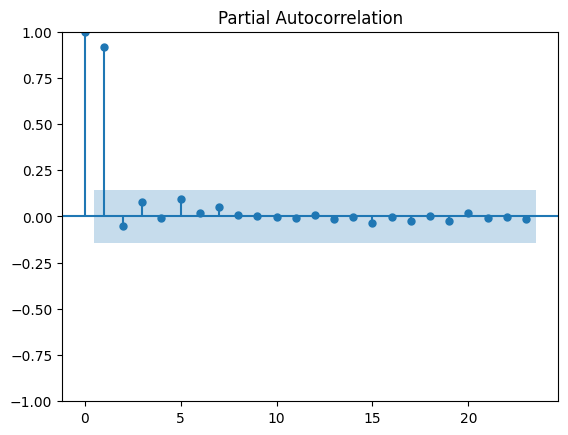

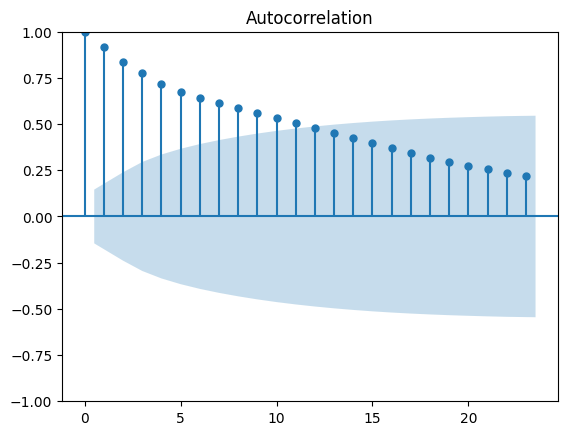

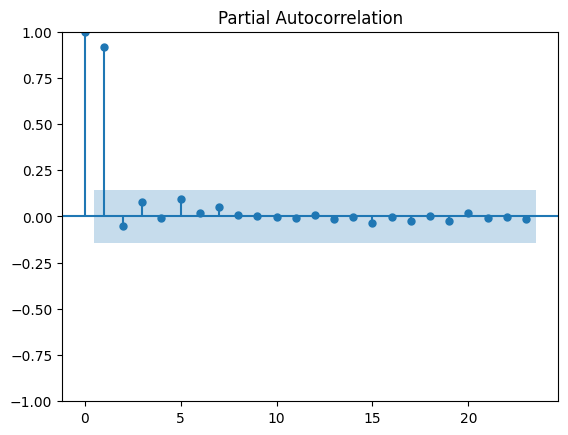

In [48]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(unemp['UNRATE'].dropna())
plot_pacf(unemp['UNRATE'].dropna())



In [49]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(unemp['UNRATE'], order = (1,1,1))
model_fit = model.fit()
print(model_fit.summary())

forecast = model_fit.forecast(steps = 12)
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                 UNRATE   No. Observations:                  181
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -219.833
Date:                Fri, 24 Apr 2026   AIC                            445.666
Time:                        20:45:43   BIC                            455.245
Sample:                             0   HQIC                           449.550
                                - 181                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8235      0.206      4.005      0.000       0.420       1.226
ma.L1         -0.9312      0.175     -5.327      0.000      -1.274      -0.589
sigma2         0.6726      0.021     31.771      0.0